# 10 数据子采样

> **图 10.1**：（左侧）通过连续优化得到的支撑点。（右侧）采用序列最近邻算法获取的子样本。

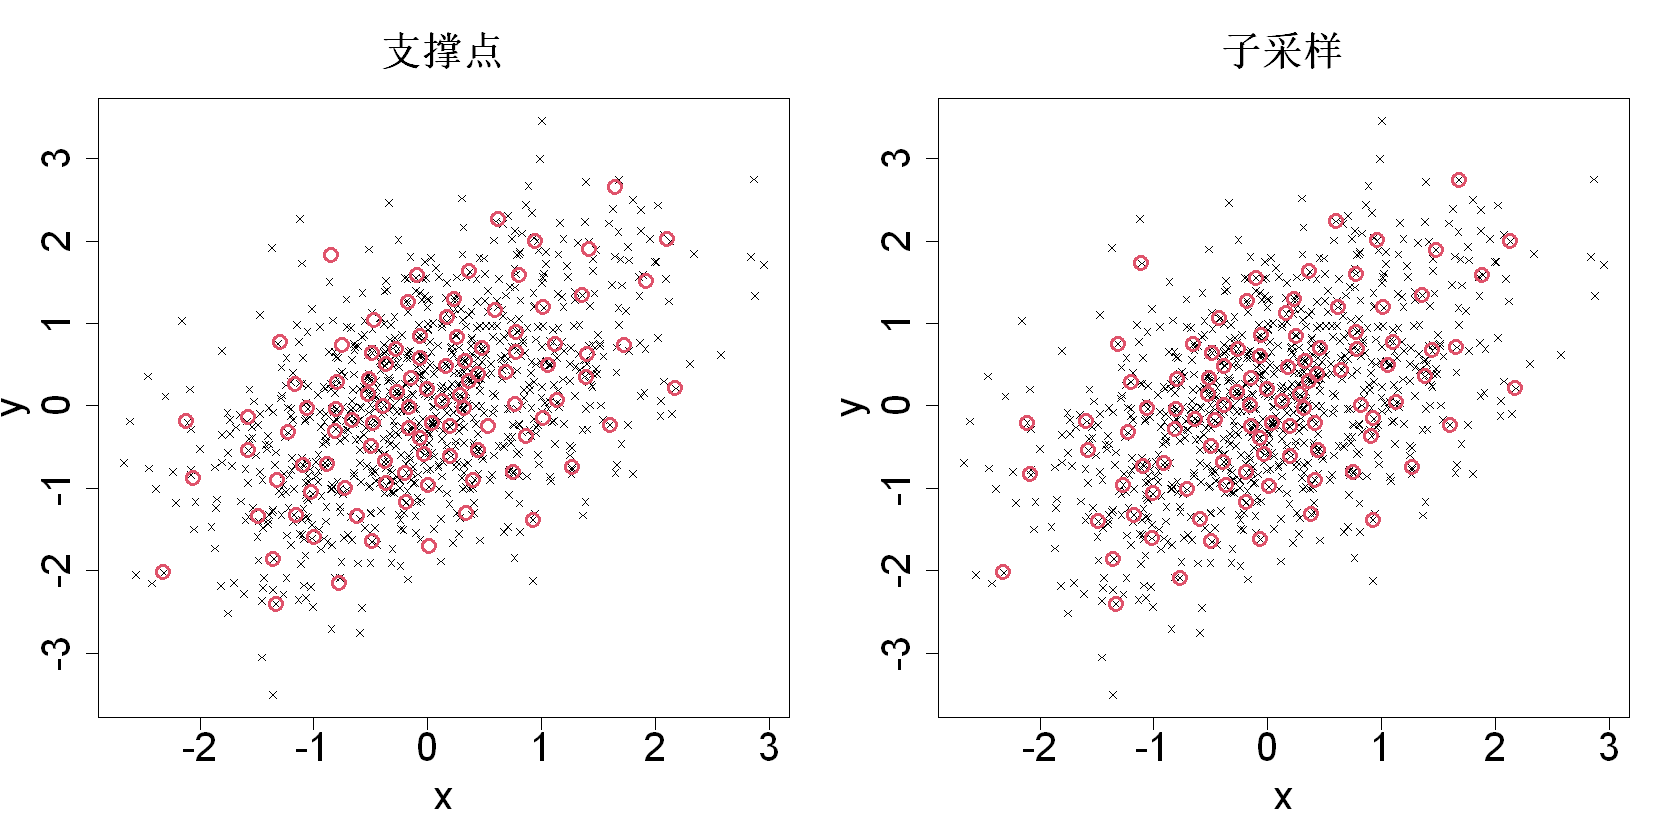

In [7]:
library(support)
library(SPlit)
library(MASS)
set.seed(123)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.1-plot.RData")){
  N=1000;p=2;rho=.5
  Sigma=diag(p)
  Sigma=rho^abs(row(Sigma)-col(Sigma))
  D=mvrnorm(n=N,mu=rep(0,p),Sigma=Sigma)
  n=100
  S=sp(n,p,dist.samp=D)$sp
  ind=subsample(D,S)
  save(D,S,ind,file="data/10.1-plot.RData")
} else load("data/10.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(D,pch=4,cex=.75,lwd=1,main="支撑点",cex.main=2,xlab="x",ylab="y",cex.lab=2,cex.axis=2)
points(S,pch=1,col=2,lwd=3,cex=1.5)
plot(D,pch=4,cex=.75,lwd=1,main="子采样",cex.main=2,xlab="x",ylab="y",cex.lab=2,cex.axis=2)
points(D[ind,],pch=1,col=2,lwd=3,cex=1.5)

> **图 10.2**：该图展示了从规模为 39195 的风电数据集中抽取的 392 个子样本，以及利用该子样本拟合得到的高斯过程（GP）模型。

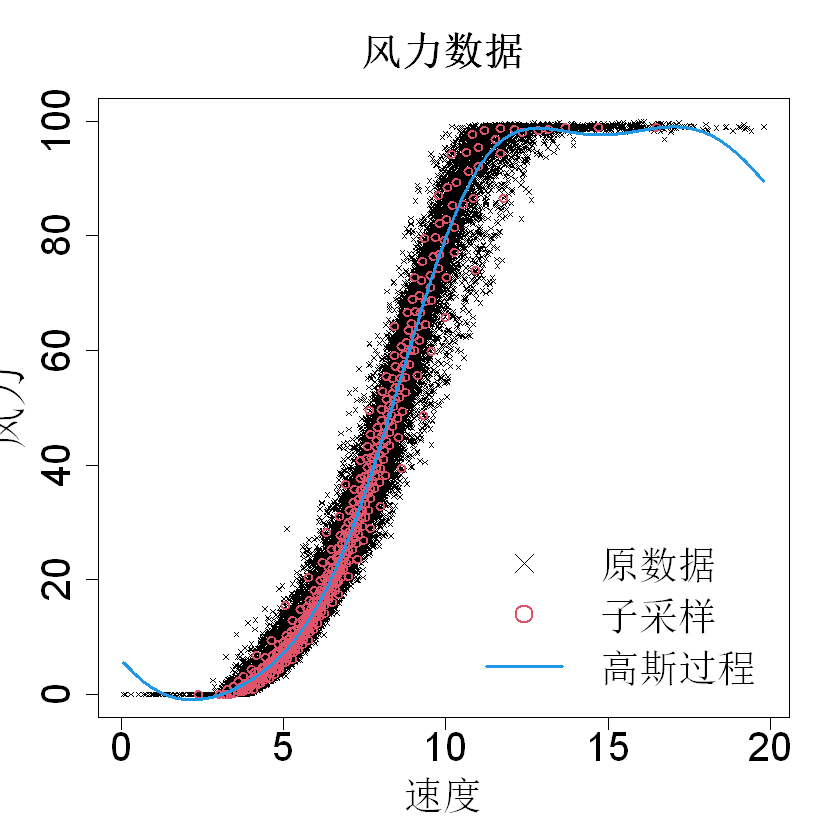

In [8]:
library(rkriging)
set.seed(123)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.2-plot.RData")){
  library(support)
  library(SPlit)
  wind=read.csv("data/wind10.csv",header=TRUE)
  p=2
  D=as.matrix(wind[,-1])
  n=392
  system.time({S=sp(n,p,dist.samp = D)$sp
    ind=subsample(D,S)})
  S=D[ind,]
  pdf(NULL)
  system.time({a=Fit.Kriging(X=cbind(S[,1]),y=S[,2],kernel.parameters = list(type="Gaussian"),interpolation = FALSE)})
  dev.off()
  ev=seq(min(D[,1]),max(D[,1]),length=1000)
  pred=Predict.Kriging(a,cbind(ev))$mean
  save(D,S,ev,pred,file="data/10.2-plot.RData")
} else load("data/10.2-plot.RData")

options(repr.plot.width=7,repr.plot.height=7)
plot(D,pch=4,cex=.5,main="风力数据",xlab="速度",ylab="风力",cex.main=2,cex.lab=2,cex.axis=2)
points(S,col=2,lwd=2)
lines(ev,pred,col=4,lwd=3)
legend("bottomright",legend=c("原数据","子采样","高斯过程"),bty="n",pch=c(4,1,NA),lty=c(NA,NA,1),col=c(1,2,4),cex=2,lwd=c(1,2,3))

> **图 10.3**：通过随机采样（左侧）和支撑点划分（右侧）选取的测试点（圆形）。三种响应类别分别以红色三角形、绿色加号和蓝色叉号表示。

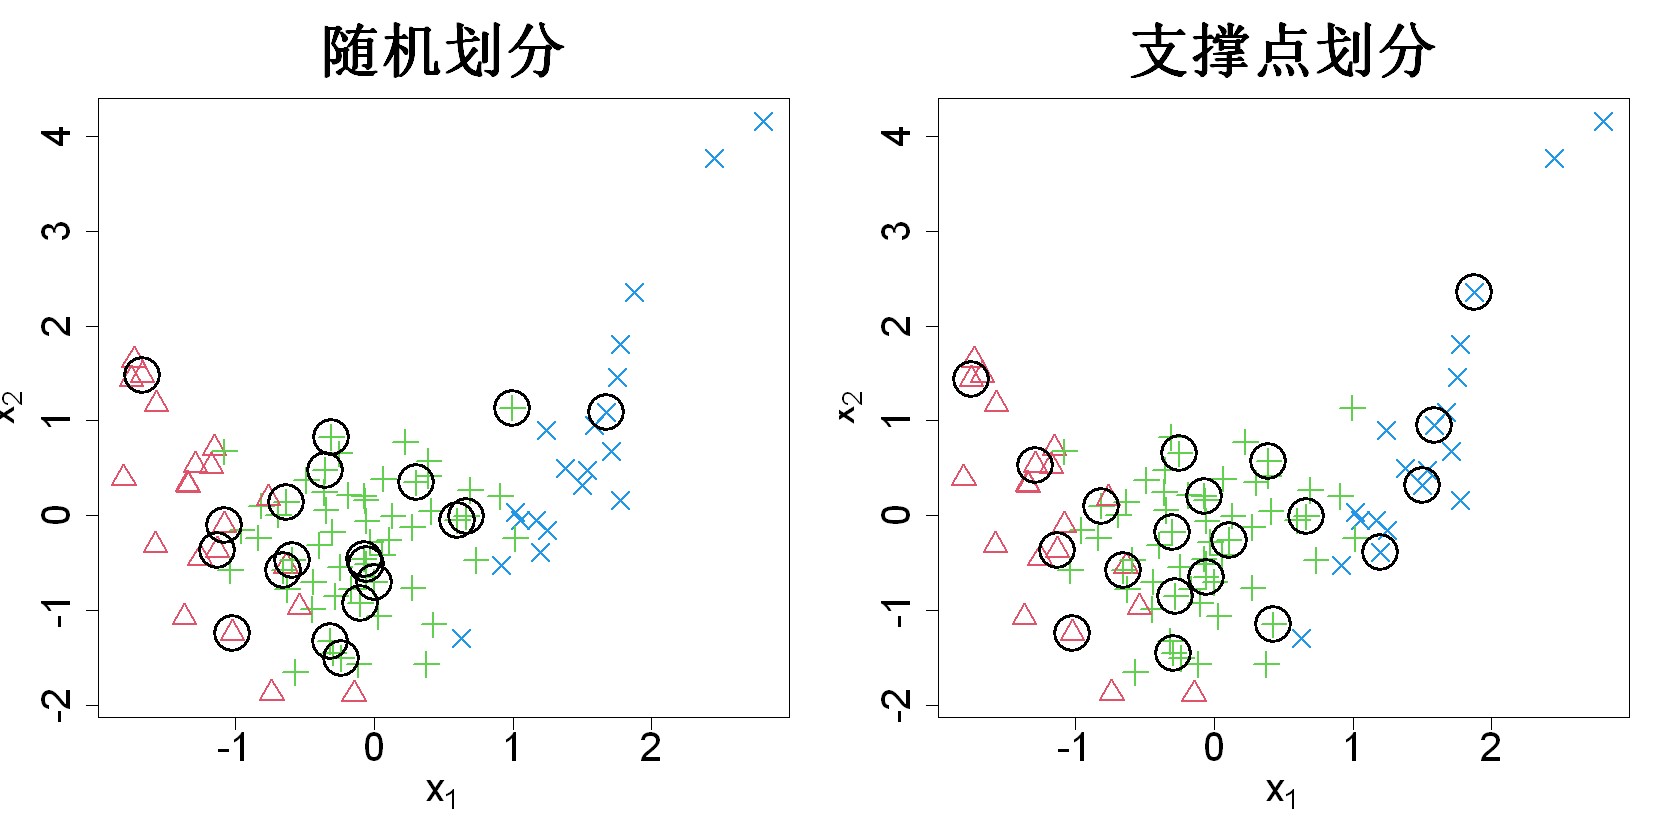

In [9]:
library(SPlit)
set.seed(102)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.3-plot.RData")){
  N=100
  x1=scale(rnorm(N))
  x2=scale(x1^2+rnorm(N))
  D=matrix(cbind(x1,x2),ncol=2)
  Ntest=20
  y=rep(2,N)
  y[rbinom(N,1,pnorm(-(6*x1+x2+5)))==1]=1
  y[rbinom(N,1,pnorm(-(-6*x1+x2+5)))==1]=3
  Dy=data.frame(x1=D[,1],x2=D[,2],y=as.factor(y))
  ind.opt=SPlit(Dy,splitRatio = .2)
  ind=sample(1:N,Ntest)
  save(x1,x2,y,D,ind,ind.opt,file="data/10.3-plot.RData")
} else load("data/10.3-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(x1,x2,pch=y+1,col=y+1,cex.lab=2, main="随机划分",xlab=expression(x[1]), ylab=expression(x[2]),cex.main=3, cex.axis=2, cex=2,lwd=2)
points(D[ind,],col=1,pch=1,lwd=3,cex=4)
Dtest=D[ind.opt,1:2]
plot(x1,x2,pch=y+1,col=y+1,cex.lab=2, main="支撑点划分",xlab=expression(x[1]), ylab=expression(x[2]),cex.main=3, cex.axis=2, cex=2,lwd=2)
points(Dtest,col=1,pch=1,lwd=3,cex=4)

> **图 10.4**：用于从 50 个点中选取 10 个点的孪生算法的第一次、第二次以及第十次迭代。

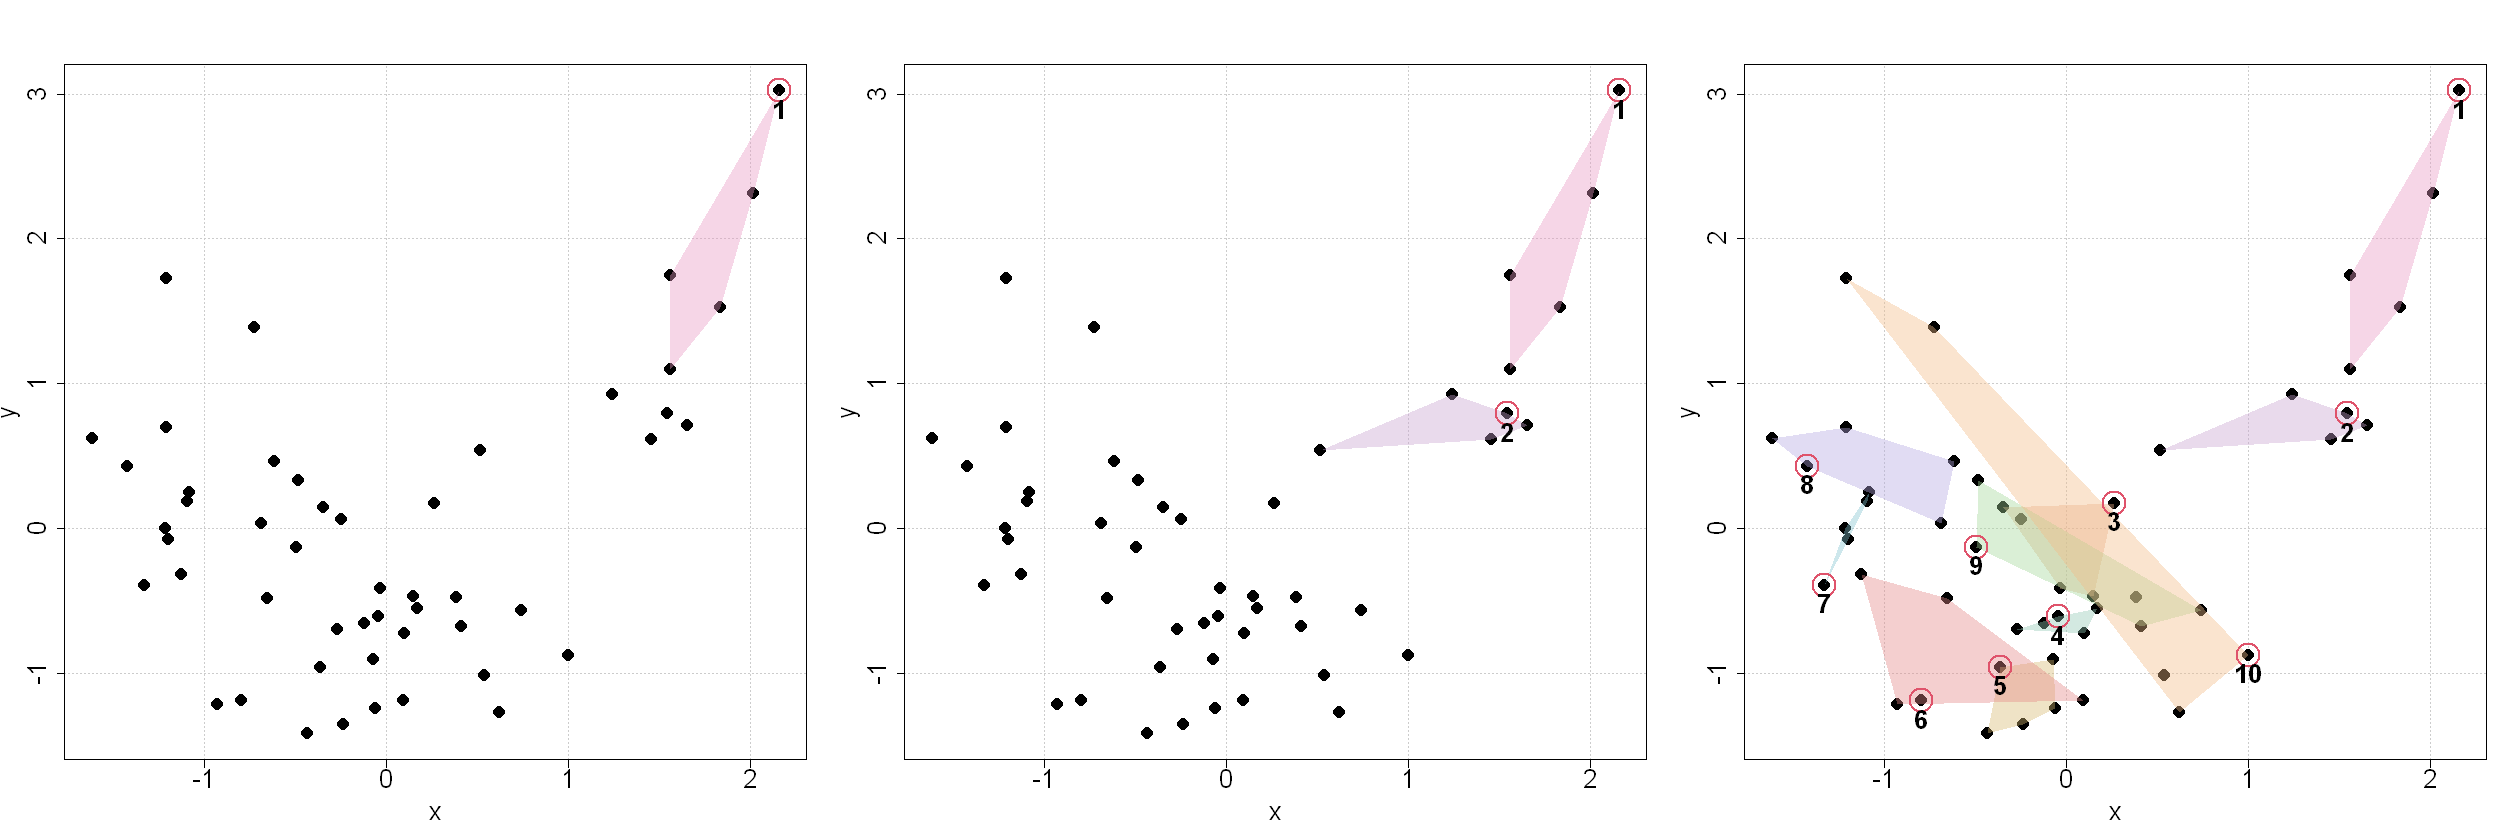

In [10]:
set.seed(6)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.4-plot.RData")){
  twin_manual=function(D,r){
    n=nrow(D)
    k=floor(n/r)
    dist_mat=as.matrix(dist(D))
    selected=integer(k)
    poly_neigh=vector("list",k)
    assigned=logical(n)
    i0=which.max(rowSums(dist_mat))
    selected[1]=i0
    assigned[i0]=TRUE
    idx_nei1=order(dist_mat[i0,])[2:(1+r-1)]
    assigned[idx_nei1]=TRUE
    poly_neigh[[1]]=idx_nei1
    for(m in 2:k){
      prev_test=selected[m-1]
      nei_prev=poly_neigh[[m-1]]
      d_to_prev=dist_mat[prev_test,nei_prev]
      Q_idx=nei_prev[which.max(d_to_prev)]
      unassigned=which(!assigned)
      d_Q=dist_mat[Q_idx,unassigned]
      next_test=unassigned[which.min(d_Q)]
      selected[m]=next_test
      assigned[next_test]=TRUE
      new_nei=order(dist_mat[next_test,])
      new_nei=new_nei[!assigned[new_nei]][1:(r-1)]
      assigned[new_nei]=TRUE
      poly_neigh[[m]]=new_nei
    }
    list(selected=selected,poly_neigh=poly_neigh)
  }
  N=50
  x=scale(rnorm(N))
  y=scale(x^2+rnorm(N))
  D=cbind(x,y)
  res=twin_manual(D,r=5)
  ind_seq=res$selected
  poly_neigh_list=res$poly_neigh
  dist_mat=as.matrix(dist(D))
  save(D,ind_seq,poly_neigh_list,file="data/10.4-plot.RData")
} else load("data/10.4-plot.RData")

col_set=c("#e898c2","#c8a2d0","#e9ad88","#92c8b4","#d8b870","#e48888","#82c2d0","#b4a8e0","#a2d898","#f2bc88")
options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot_iter=function(iter_max,mainlab){
  plot(D,pch=16,cex=2,xlab="x",ylab="y",cex.axis=2,cex.lab=2,panel.first=grid(col="grey80"))
  for(m in 1:iter_max){
    this_test_idx=ind_seq[m]
    neigh_idx=poly_neigh_list[[m]]
    poly_pts=D[c(this_test_idx,neigh_idx),]
    ch=chull(poly_pts)
    polygon(poly_pts[ch,],col=adjustcolor(col_set[m],alpha.f=0.4),border=NA)
  }
  sel=ind_seq[1:iter_max]
  pts_sel=D[sel,,drop=FALSE]
  points(pts_sel,col=2,cex=4,lwd=2)
  text(x=pts_sel[,1],y=pts_sel[,2]-0.12,labels=1:iter_max,col=1,cex=2,font=2)
}
plot_iter(1,"(A) Iteration 1")
plot_iter(2,"(B) Iteration 2")
plot_iter(10,"(C) Iteration 10")

> **图 10.5**：支撑点划分法、孪生法与局部枢轴法用于空间均衡抽样。能量距离与空间均衡度量的数值越小，代表样本分布越分散，能够较好地代表总体。

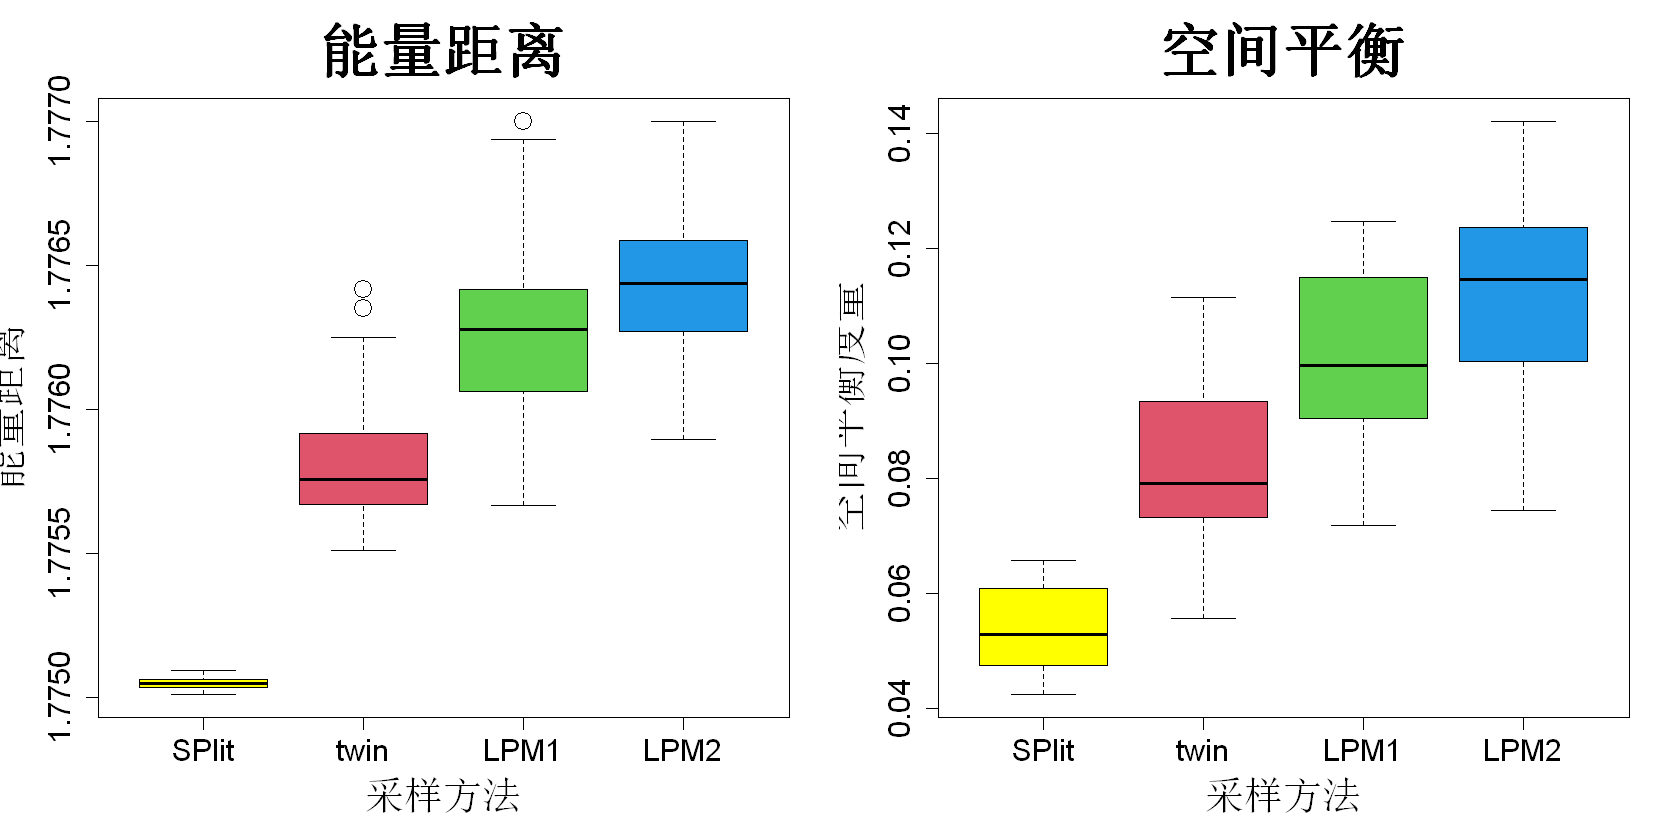

In [11]:
set.seed(4)
library(twinning)
library(SPlit)
library(BalancedSampling)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.5-plot.RData")){
N=1000
X=matrix(rnorm(2*N),ncol=2)
n=100
edsplit=edtwin=edlpm1=edlpm2=numeric(30)
sbsplit=sbtwin=sblpm1=sblpm2=numeric(30)
for(i in 1:30){
  ind=SPlit(X,splitRatio = n/N)
  edsplit[i]=energy(X,X[ind,])
  sbsplit[i]=sb(rep(n/N,N),X,ind)
  
  ind=twin(X,r=N/n)
  edtwin[i]=energy(X,X[ind,])
  sbtwin[i]=sb(rep(n/N,N),X,ind)
  
  ind=lpm1(rep(n/N,N),X)
  edlpm1[i]=energy(X,X[ind,])
  sblpm1[i]=sb(rep(n/N,N),X,ind)
  
  ind=lpm2(rep(n/N,N),X)
  edlpm2[i]=energy(X,X[ind,])
  sblpm2[i]=sb(rep(n/N,N),X,ind)
}
  save(edsplit,edtwin,edlpm1,edlpm2,sbsplit,sbtwin,sblpm1,sblpm2,file="data/10.5-plot.RData")
} else load("data/10.5-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
ed=data.frame(SPlit=edsplit,twin=edtwin,LPM1=edlpm1,LPM2=edlpm2)
boxplot(ed,main="能量距离",xlab="采样方法",ylab="能量距离",cex.main=3,cex.axis=1.5,cex=2,cex.lab=2,col=c("yellow",2:4))
sbmeasure=data.frame(SPlit=sbsplit,twin=sbtwin,LPM1=sblpm1,LPM2=sblpm2)
boxplot(sbmeasure,main="空间平衡",xlab="采样方法",ylab="空间平衡度量",cex.main=3,cex.axis=1.5,cex=2,cex.lab=2,col=c("yellow",2:4))

> **图 10.6**：从 10000 个样本中分别通过 k 均值算法（左）与有监督压缩算法（右）选出 100 个样本点。样本点叠加在用于生成数据的米哈伊维奇函数图像之上。

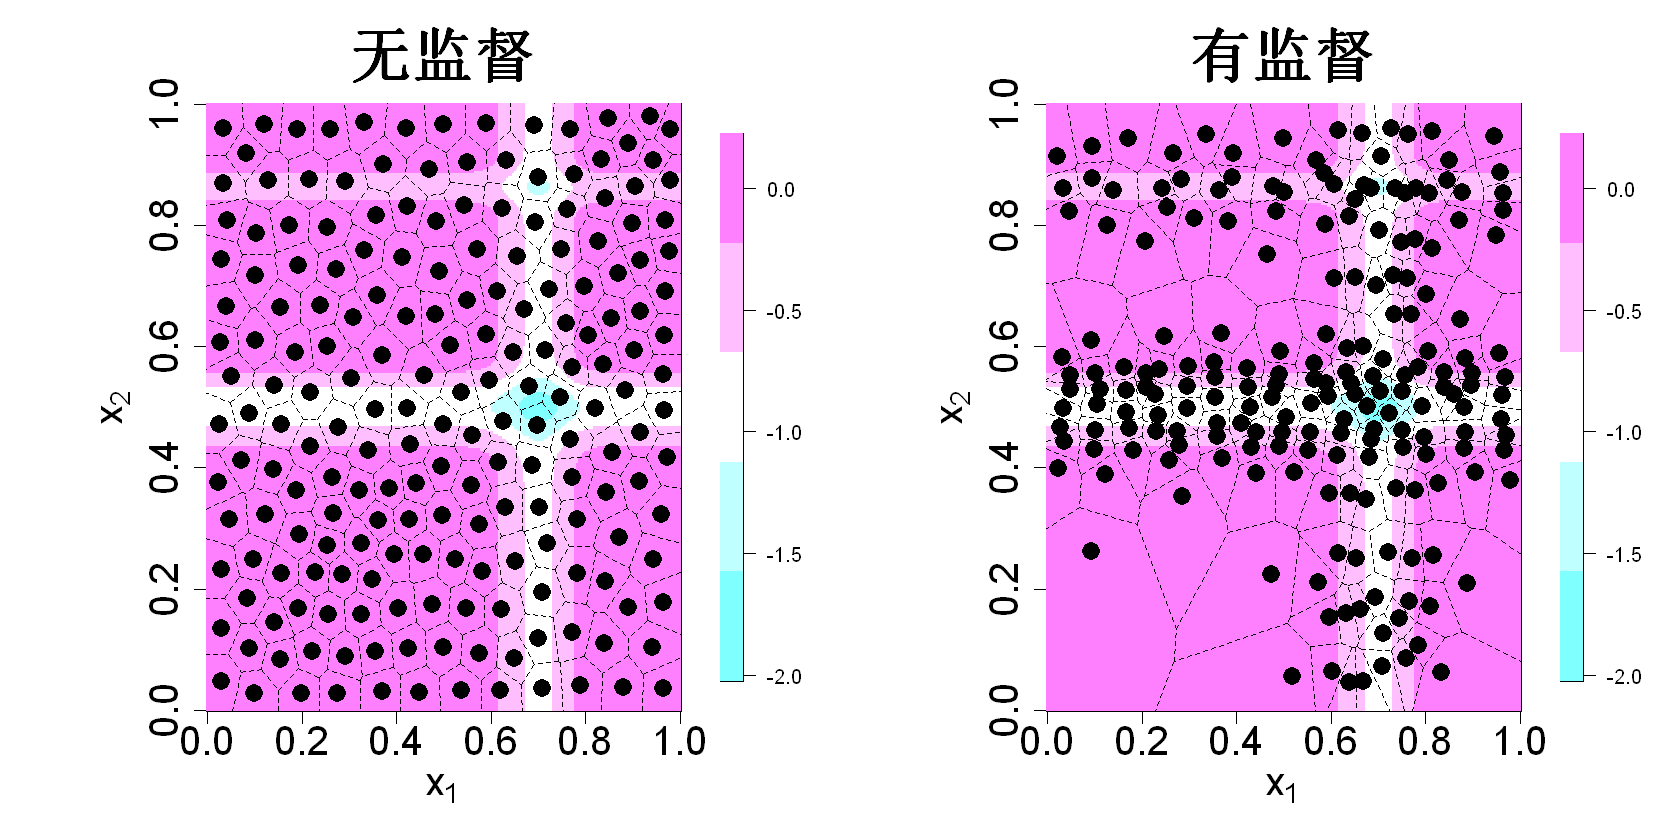

In [12]:
library(supercompress)
library(deldir)
library(FNN)
library(fields)
set.seed(1)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/10.6-plot.RData")){
  f=function(x){
    p=length(x)
    x=pi*x
    val=-sum(sin(x)*(sin((1:p)*x^2/pi))^(20))
    return(val)
  }
  p=2
  N=10000*p
  x=NULL
  for(i in 1:p) x=cbind(x,runif(N))
  y=apply(x,1,f)+.01*rnorm(N)
  n=200
  true=apply(x,1,f)
  N.plot=250
  p1=seq(0,1,length=N.plot)
  p2=seq(0,1,length=N.plot)
  fc=matrix(apply(expand.grid(p1,p2),1,f),nrow=N.plot, ncol= N.plot)
  system.time({
    a0=kmeans(x,n,iter.max=100)})
  D0=a0$centers
  cluster=a0$cluster
  y0=sapply(split(y,cluster),mean)
  pred.nn=knn.reg(D0,test=x,y0,k=1)$pred
  system.time({a=supercompress(n,x,y)})
  Dopt=a$D
  ybar=a$ybar
  pred.nn=knn.reg(Dopt,test=x,ybar,k=1)$pred
  save(p1,p2,fc,D0,Dopt,file="data/10.6-plot.RData")
} else load("data/10.6-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
imagePlot(p1,p2,fc,col=cm.colors(5),xlab=expression(x[1]),ylab=expression(x[2]),main="无监督",cex.main=3,cex.lab=2, cex.axis=2)
points(D0,pch=16,col=1,cex=2)
vor=deldir(D0[,1],D0[,2])
plot.deldir(vor,add=TRUE,wlines="tess")
imagePlot(p1,p2,fc,col=cm.colors(5),xlab=expression(x[1]),ylab=expression(x[2]),main="有监督",cex.main=3,cex.lab=2, cex.axis=2)
points(Dopt,pch=16,col=1,cex=2)
vor=deldir(Dopt[,1],Dopt[,2])
plot.deldir(vor,add=TRUE,wlines="tess")